<a href="https://colab.research.google.com/github/olucasaguiar/estudos-sobre-machine-learning/blob/main/temas/natural-language-processing/NLP_lucas_nascimento_aguiar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sobre o dataset

O UTLCorpus, proveniente do projeto Opinando, é um corpus com mais de 2 milhões de avaliações. Ele engloba resenhas de filmes coletadas do Filmow, uma popular rede social de filmes, e foi tratado especificamente como UTLC-Movies neste contexto, com todas as avaliações que possuíam classificação 0 removidas para garantir a qualidade dos dados.

In [1]:
# @title Carregando o dataset
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter


def load_dataset(handle: str, path: str) -> pd.DataFrame:
    return kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        handle,
        path,
    )

In [2]:
import numpy as np


dataset_handle = "fredericods/ptbr-sentiment-analysis-datasets"
dataset_file = "utlc_movies.csv"

df = load_dataset(handle=dataset_handle, path=dataset_file)
df = df[["review_text", "polarity", "rating"]]

### Reduzi o tamanho do dataset para acelerar o treinamento do modelo
TEST_SIZE = 10_000
### Para garantir a mesma proporção do conjunto de testes para classificação 1/0
FOLD_SIZE = TEST_SIZE // 2
positive_samples = df[df["polarity"] == 1].sample(
    n=FOLD_SIZE,
    random_state=42,
)
negative_samples = df[df["polarity"] == 0].sample(
    n=FOLD_SIZE,
    random_state=42,
)

df = (
    pd.concat([positive_samples, negative_samples], ignore_index=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(df.info())
print(df.head())

100%|██████████| 318M/318M [00:06<00:00, 53.0MB/s]

Extracting zip of utlc_movies.csv...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_text  10000 non-null  object 
 1   polarity     10000 non-null  float64
 2   rating       10000 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB
None
                                         review_text  polarity  rating
0  Horrível! Filme cansativo, arrastado, com ator...       0.0       1
1  Sem dúvidas posso afirmar que é um dos melhore...       1.0       5
2                                            Ameii!!       1.0       5
3  Não desmerecendo as outras atrizes, mas eu fic...       1.0       4
4  Maravilhoso! Eu juro q não dava nada pelo film...       1.0       5


In [3]:
# @title Preparando o dataset
import nltk
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

TrainSet = tuple[pd.DataFrame, pd.Series]
TestSet = tuple[pd.DataFrame, pd.Series]


def prepare_dataset(
    feature_values: pd.DataFrame | pd.Series,
    target_values: pd.DataFrame | pd.Series,
    max_features: int | None = None,
    max_df: float = 1.0,
    min_df: int | float = 1,
    norm: str | None = "l2",
) -> tuple[TfidfVectorizer, TrainSet, TestSet]:
    # step 1: Split test and train data
    X_train, X_test, y_train, y_test = train_test_split(
        feature_values, target_values, test_size=0.33, random_state=42, shuffle=True
    )

    # step 2: Create TF-IDF Vectorizer for documents vocabulary
    nltk.download("stopwords")
    vectorizer = TfidfVectorizer(
        strip_accents="ascii",
        stop_words=stopwords.words("portuguese"),
        norm=norm,
        max_df=max_df,
        min_df=min_df,
        max_features=max_features,
    )

    # step 3: Fit data into vetorizer/tokenizer and transform feature_data
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)

    # step 4: Return train and test datasets
    return vectorizer, (X_train, y_train), (X_test, y_test)

In [4]:
vectorizer, (X_train, y_train), (X_test, y_test) = prepare_dataset(
    feature_values=df["review_text"], target_values=df["polarity"]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ate', 'eramos', 'estao', 'estavamos', 'estiveramos', 'estivessemos', 'foramos', 'fossemos', 'ha', 'hao', 'houveramos', 'houverao', 'houveriamos', 'houvessemos', 'ja', 'nao', 'sao', 'sera', 'serao', 'seriamos', 'so', 'tambem', 'tera', 'terao', 'teriamos', 'tinhamos', 'tiveramos', 'tivessemos', 'voce', 'voces'] not in stop_words.
  warnings.warn(


In [5]:
import numpy as np

print("| qtd. documentos | tam. vocabulario |")
print("| --------------- | ---------------- |")
print("| %15d | %16d |" % X_train.shape)

| qtd. documentos | tam. vocabulario |
| --------------- | ---------------- |
|            6700 |            19492 |


In [52]:
# @title Aplicando o treinamento do modelo supervisionado
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


# clf = MLPClassifier()
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

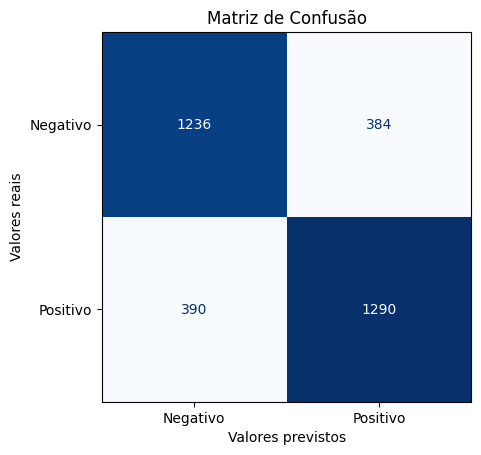


Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76      1620
         1.0       0.77      0.77      0.77      1680

    accuracy                           0.77      3300
   macro avg       0.77      0.77      0.77      3300
weighted avg       0.77      0.77      0.77      3300



In [80]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, display_labels=["Negativo", "Positivo"])
disp.im_.colorbar.remove()
disp.ax_.set_title("Matriz de Confusão")
disp.ax_.set_xlabel("Valores previstos")
disp.ax_.set_ylabel("Valores reais")
plt.show()


In [7]:
# @title Gerando dados simulados com LLM
from google import genai
from google.colab import userdata
from google.genai import types


def generate_content(
    prompt: str,
    model: str = "gemini-2.5-flash-lite",
    system_instruction: str | None = None,
    temperature: float | None = None,
    top_p: float | None = None,
) -> str:
    try:
        genai_api_key = userdata.get("GOOGLE_API_KEY")
    except userdata.SecretNotFoundError as e:
        print(
            'Secret not found. Configure secret for Gemini Models using secret variable "GOOGLE_API_KEY".'
        )
        raise e

    with genai.Client(api_key=genai_api_key) as client:
        response = client.models.generate_content(
            model=model,
            contents=types.Part.from_text(text=prompt),
            config=types.GenerateContentConfig(
                system_instruction=system_instruction,
                temperature=temperature,
                top_p=top_p,
            ),
        )
        return response.text

In [113]:
from io import StringIO

import pandas as pd
from sklearn.utils import shuffle

few_shot_prompt = """
Prepare um conjunto de dados estruturados no formato `.csv` no idioma português (pt_BR) com as dimensões:
- **index**: Valor numérico sequêncial iniciando em 1;
- **review_text**: Um texto entre 5 e 25 palavras contendo a opinião sobre um filme qualquer;
- **polarity**: A intenção do comentário, onde 0 representa negativo e 1 representa positivo.

Cada linha deve simular a avaliação de uma pessoa diferente, com suas características únicas e pessoais.
O público respondente possui faixa etária de 20 à 45 anos, e variação demográfica (genêro, contexto social, crença, etc).

**Exemplos**

Usuário: Prepare um conjunto de 5 analises positivas e 5 análises negativas
Resposta:
```csv
{first_example}
```

Usuário: Prepare um conjunto de 3 analises positivas e 5 análises negativas
Resposta:
```csv
{second_example}
```

**Solicitação**
Usuário: Prepare um conjunto de {n_positive} análises positivas e {n_negative} análises negativas
Resposta:
""".strip()


def simulate_review(n_positive: int, n_negative: int, first_example: str, second_example: str) -> pd.DataFrame:
    prompt = few_shot_prompt.format(first_example=first_example, second_example=second_example, n_positive=n_positive, n_negative=n_negative)
    response = generate_content(prompt=prompt, model='gemini-2.5-flash-lite', temperature=0.3, top_p=1.0)

    if response.startswith("```csv"):
        response = response[6:]

    if response.endswith("```"):
        response = response[:-3]

    buffer = StringIO(response.strip())
    review_df = pd.read_csv(buffer)
    review_df = shuffle(review_df, random_state=42).reset_index(drop=True)
    return review_df[["review_text", "polarity"]]

In [99]:
import pandas as pd
import csv

positive_filter = df['polarity'] == 1
negative_filter = df['polarity'] == 0

index_label = 'index'
columns = ['review_text', 'polarity']
example_1 = pd.concat([df[positive_filter].sample(n=5), df[negative_filter].sample(n=5)], ignore_index=True)
example_1_str = example_1.to_csv(index=True, columns=columns,index_label=index_label, quoting=csv.QUOTE_NONNUMERIC)

example_2 = pd.concat([df[positive_filter].sample(n=3), df[negative_filter].sample(n=5)], ignore_index=True)
example_2_str = example_2.to_csv(index=True, columns=columns,index_label=index_label, quoting=csv.QUOTE_NONNUMERIC)

In [114]:
llm_data = simulate_review(n_positive=50, n_negative=50, first_example=example_1_str, second_example=example_2_str)

print(llm_data['polarity'].value_counts())
print(llm_data.head())

polarity
0.0    50
1.0    50
Name: count, dtype: int64
                                         review_text  polarity
0  Detestei a falta de desenvolvimento. Os person...       0.0
1  Péssimo! A direção é amadora, a fotografia é e...       0.0
2  Que filme sem alma. A falta de paixão e de emo...       0.0
3  Que filme espetacular! A ação é intensa e o su...       1.0
4  Simplesmente perfeito! A forma como aborda tem...       1.0


In [115]:
X_llm_test = vectorizer.transform(llm_data["review_text"])
y_llm_pred = clf.predict(X_llm_test)

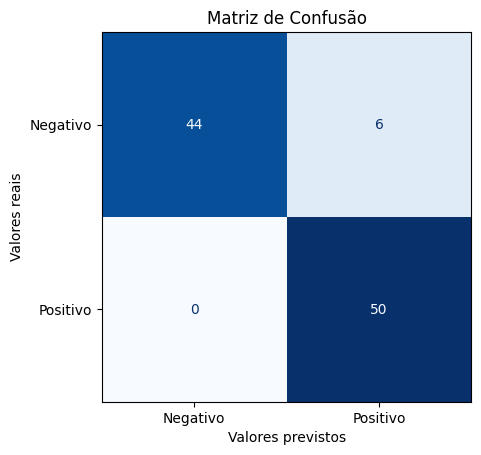

In [116]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


disp = ConfusionMatrixDisplay.from_predictions(llm_data["polarity"], y_llm_pred, cmap=plt.cm.Blues, display_labels=["Negativo", "Positivo"])
disp.im_.colorbar.remove()
disp.ax_.set_title("Matriz de Confusão")
disp.ax_.set_xlabel("Valores previstos")
disp.ax_.set_ylabel("Valores reais")
plt.show()

In [117]:
print("Relatório conjunto de teste")
print(classification_report(y_test, y_pred))

print("Relatório conjunto gerado por LLM")
print(classification_report(llm_data["polarity"], y_llm_pred))

Relatório conjunto de teste
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76      1620
         1.0       0.77      0.77      0.77      1680

    accuracy                           0.77      3300
   macro avg       0.77      0.77      0.77      3300
weighted avg       0.77      0.77      0.77      3300

Relatório conjunto gerado por LLM
              precision    recall  f1-score   support

         0.0       1.00      0.88      0.94        50
         1.0       0.89      1.00      0.94        50

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.95      0.94      0.94       100



## Resultados

Ao comparar os resultados do modelo com o conjunto gerado pelo LLM (ground-true), observamos uma performance notavelmente alta. O modelo alcançou uma acurácia de 0.94. As métricas de precisão, recall e f1-score são igualmente elevadas para ambas as classes (0 e 1), indicando que o modelo foi muito eficaz em classificar corretamente as análises de sentimentos geradas pelo LLM.

Entretanto, podemos realizar algumas observações em relação às métricas de precisão e recall do modelo. Para isso, vamos abordar cada uma das labels de maneira isolada:

1.  **Label 0 (negativo):** O modelo obteve uma precisão de 100% na classificação dos negativos, ou seja, todas as previsões negativas foram corretas em relação ao resultado esperado. Porém, ao observar toda a população de resultados negativos, percebe-se que o modelo deixou de classificar 6 amostras que faziam parte do conjunto negativo, fazendo com que o recall penalize o f1-score em 0.88 (cálculo: TN / (TN + FP) => 44 / (44 + 6) => 0.88).

2.  **Label 1 (positivo):** O modelo alcançou um recall de 100% para os exemplos positivos. Isso significa que ele identificou corretamente todas as 50 amostras que eram realmente positivas. No entanto, sua precisão foi de 89%, o que indica que, de todas as amostras que o modelo classificou como positivas, aproximadamente 11% (cerca de 6 amostras) eram, na verdade, negativas (Falsos Positivos). Essas amostras foram incorretamente rotuladas como positivas, reduzindo a precisão da classe. Apesar disso, o alto recall contribuiu para um f1-score robusto de 0.94.

## Conclusão

A comparação entre o desempenho do modelo no conjunto de teste original e no conjunto de dados gerado pelo LLM revela insights importantes. A performance superior no conjunto gerado pelo LLM (acurácia de 0.94) em contraste com o conjunto de teste original (acurácia de 0.77) sugere que o modelo é altamente eficaz na classificação de sentenças que são estruturalmente mais claras e consistentemente rotuladas, como as criadas pelo LLM.

No conjunto gerado pelo LLM, a alta precisão para a classe negativa (100%) e o alto recall para a classe positiva (100%) indicam que o modelo é robusto em identificar corretamente o que é negativo e em não perder nenhum exemplo positivo, respectivamente. No entanto, a ligeira queda na precisão da classe positiva (89%) e no recall da classe negativa (88%) no conjunto do LLM mostra que o modelo ainda pode cometer alguns erros de Falsos Positivos e Falsos Negativos, mesmo em dados 'limpos' gerados pelo LLM.

Essa diferença de desempenho entre os dois conjuntos de dados pode ser atribuída a vários fatores, como a maior complexidade e a variabilidade linguística inerente aos dados reais (UTLCorpus), que podem conter nuances, sarcasmo, gírias ou erros de digitação, tornando a classificação mais desafiadora. Em contrapartida, os dados gerados pelo LLM são, por design, mais controlados e alinhados com o que o modelo foi treinado a esperar.